### Imports & general setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from numpy.fft import fft, ifft
from scipy.signal import butter
from scipy import signal as sp_signal
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

In [24]:
filename = 'ken_walking_front_short'
keypoints_over_time = np.load(f'./saved_coords/validation_test/{filename}.npy')
keypoints_over_time.shape

FileNotFoundError: [Errno 2] No such file or directory: './saved_coords/validation_test/ken_walking_front_short.npy'

In [4]:
LHip = keypoints_over_time[:, 11, :]
RHip = keypoints_over_time[:, 12, :]
# LHip.shape
# Nose = keypoints_over_time[:, 0, :]
# LEye = keypoints_over_time[:, 1, :]
# REye = keypoints_over_time[:, 2, :]

RAnkle = keypoints_over_time[:, 16, :]

In [40]:
signal = RAnkle 
confidence = RAnkle[:, 2]

print(signal.shape)
print(confidence.shape)

(690, 3)
(690,)


### Replacing outliers

1. find outliers
2. replace them with NaN
3. calculate what should replace them

In [17]:
def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

In [41]:
mean = np.mean(confidence)
std = np.std(confidence)
max = np.max(confidence)
print(f'Mean: {mean}, Std: {std}, Max: {max}')

mean_plot = np.ones_like(confidence) * mean
std_plot_p = mean_plot + std
std_plot_n = mean_plot - std
std_plot_p2 = mean_plot + 2 * std
std_plot_n2 = mean_plot - 2 * std
attributes = [std_plot_p, std_plot_n, std_plot_p2, std_plot_n2]

Mean: 0.865031111413154, Std: 0.053220017326220025, Max: 1.0086452960968018


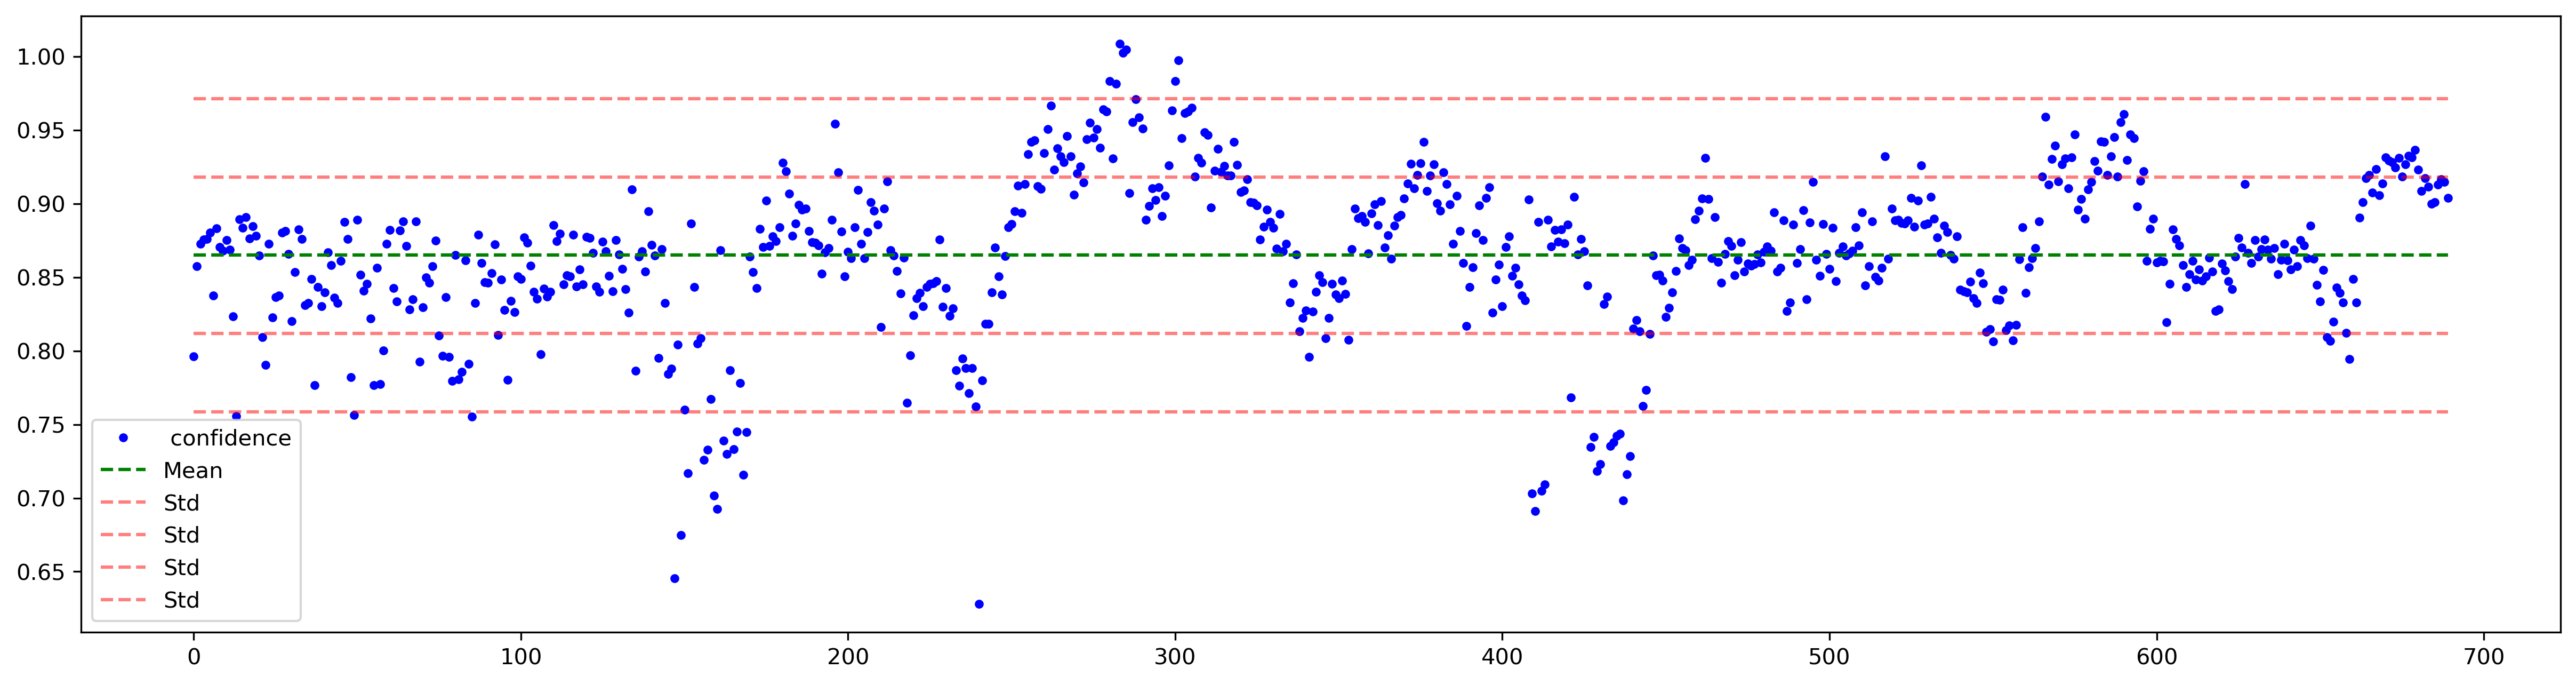

In [42]:
plt.figure(figsize=(20, 5))
plt.plot(confidence,'b.', label=' confidence')
# plt.plot(og[:,2],'rs', alpha=0.2, label='Original confidence')

plt.plot(mean_plot, 'g--', label='Mean')
# plt.plot(std_plot_p, 'r--', label='Std')
# plt.plot(std_plot_n, 'r--')

for attr in attributes:
    plt.plot(attr, 'r--', alpha=0.5, label='Std')

plt.legend()

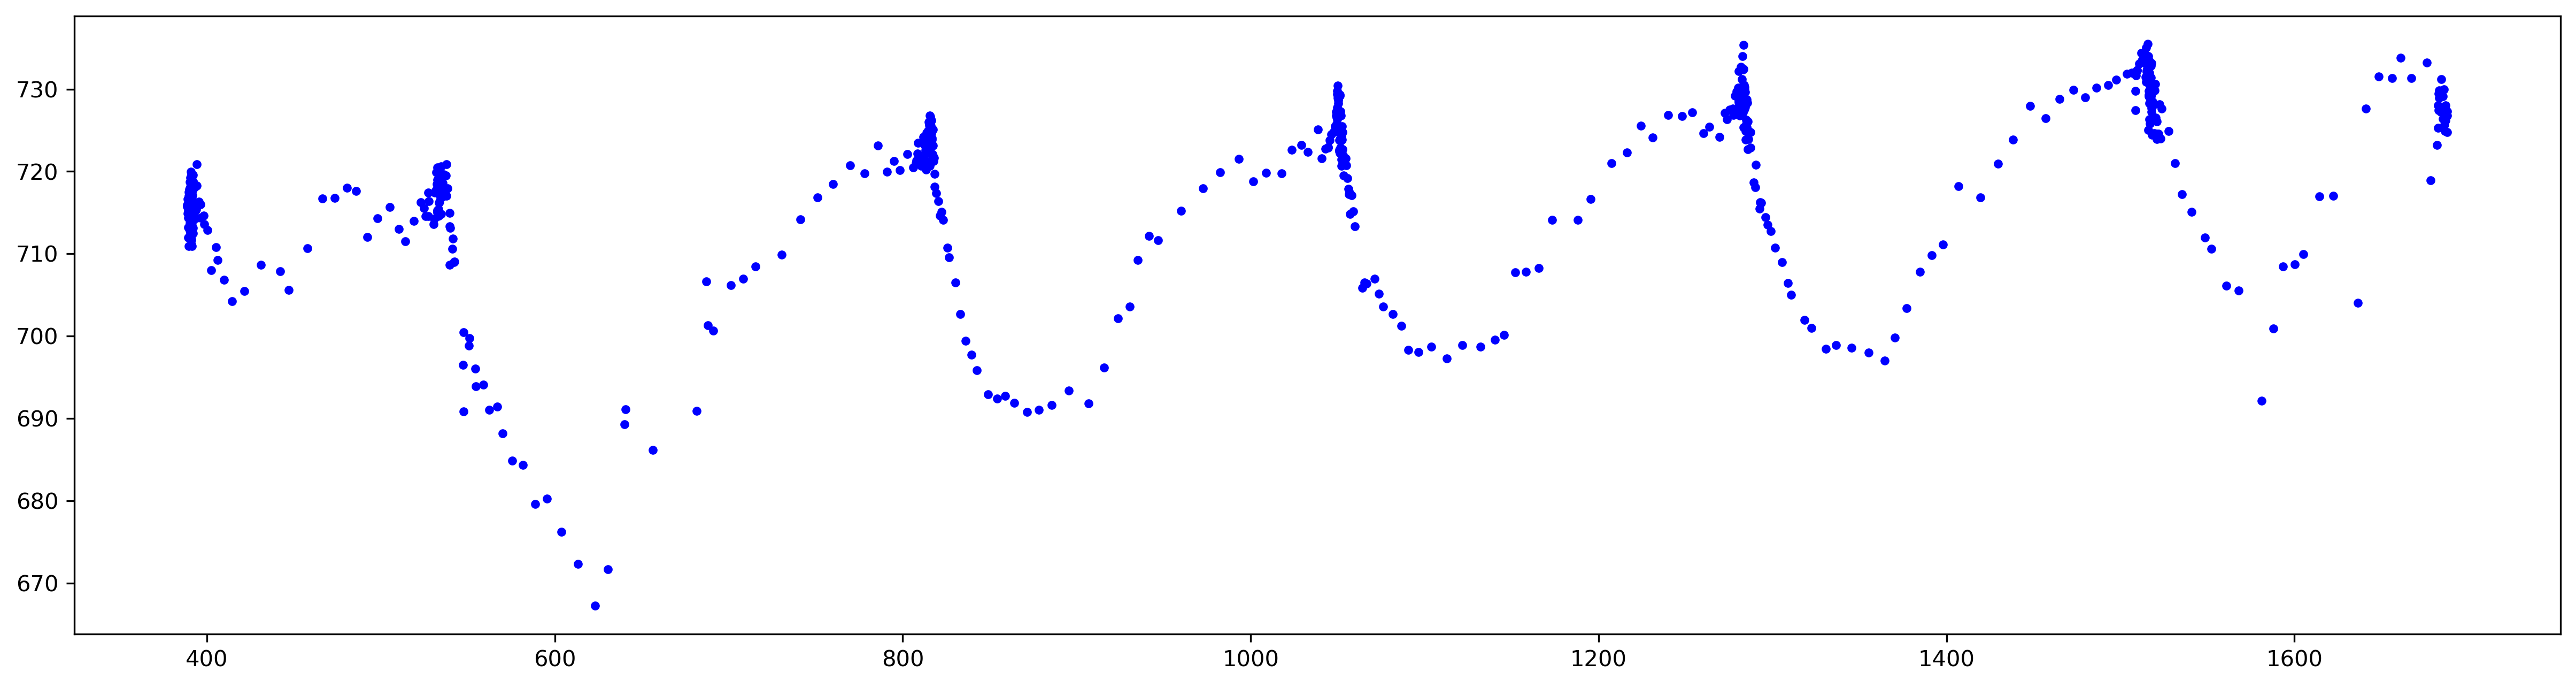

In [43]:
plt.figure(figsize=(20, 5))
plt.plot(RAnkle[:, 0], RAnkle[:, 1], 'b.', label='RAnkle')

In [61]:
confidence_thr = 0.8
confidence_max = np.max(Nose[:,2])

for i in range(30):
    for ind, (x, y, conf) in enumerate(Nose):
        # print(ind, x, y, conf)

        # there is an outlier
        if conf < confidence_thr * confidence_max and ind >0 and ind < len(Nose) - 1:
            # Nose[ind, 0] = (Nose[ind-1, 0] + Nose[ind+1, 0]) / 2
            # Nose[ind, 1] = (Nose[ind-1, 1] + Nose[ind+1, 1]) / 2
            Nose[ind, 2] = (Nose[ind-1, 2] + Nose[ind+1, 2]) / 2

            # value[0] = np.nan
            # value[1] = np.nan

### Filtering

c:\Users\unger\miniconda3\envs\stereo_vision\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\unger\miniconda3\envs\stereo_vision\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


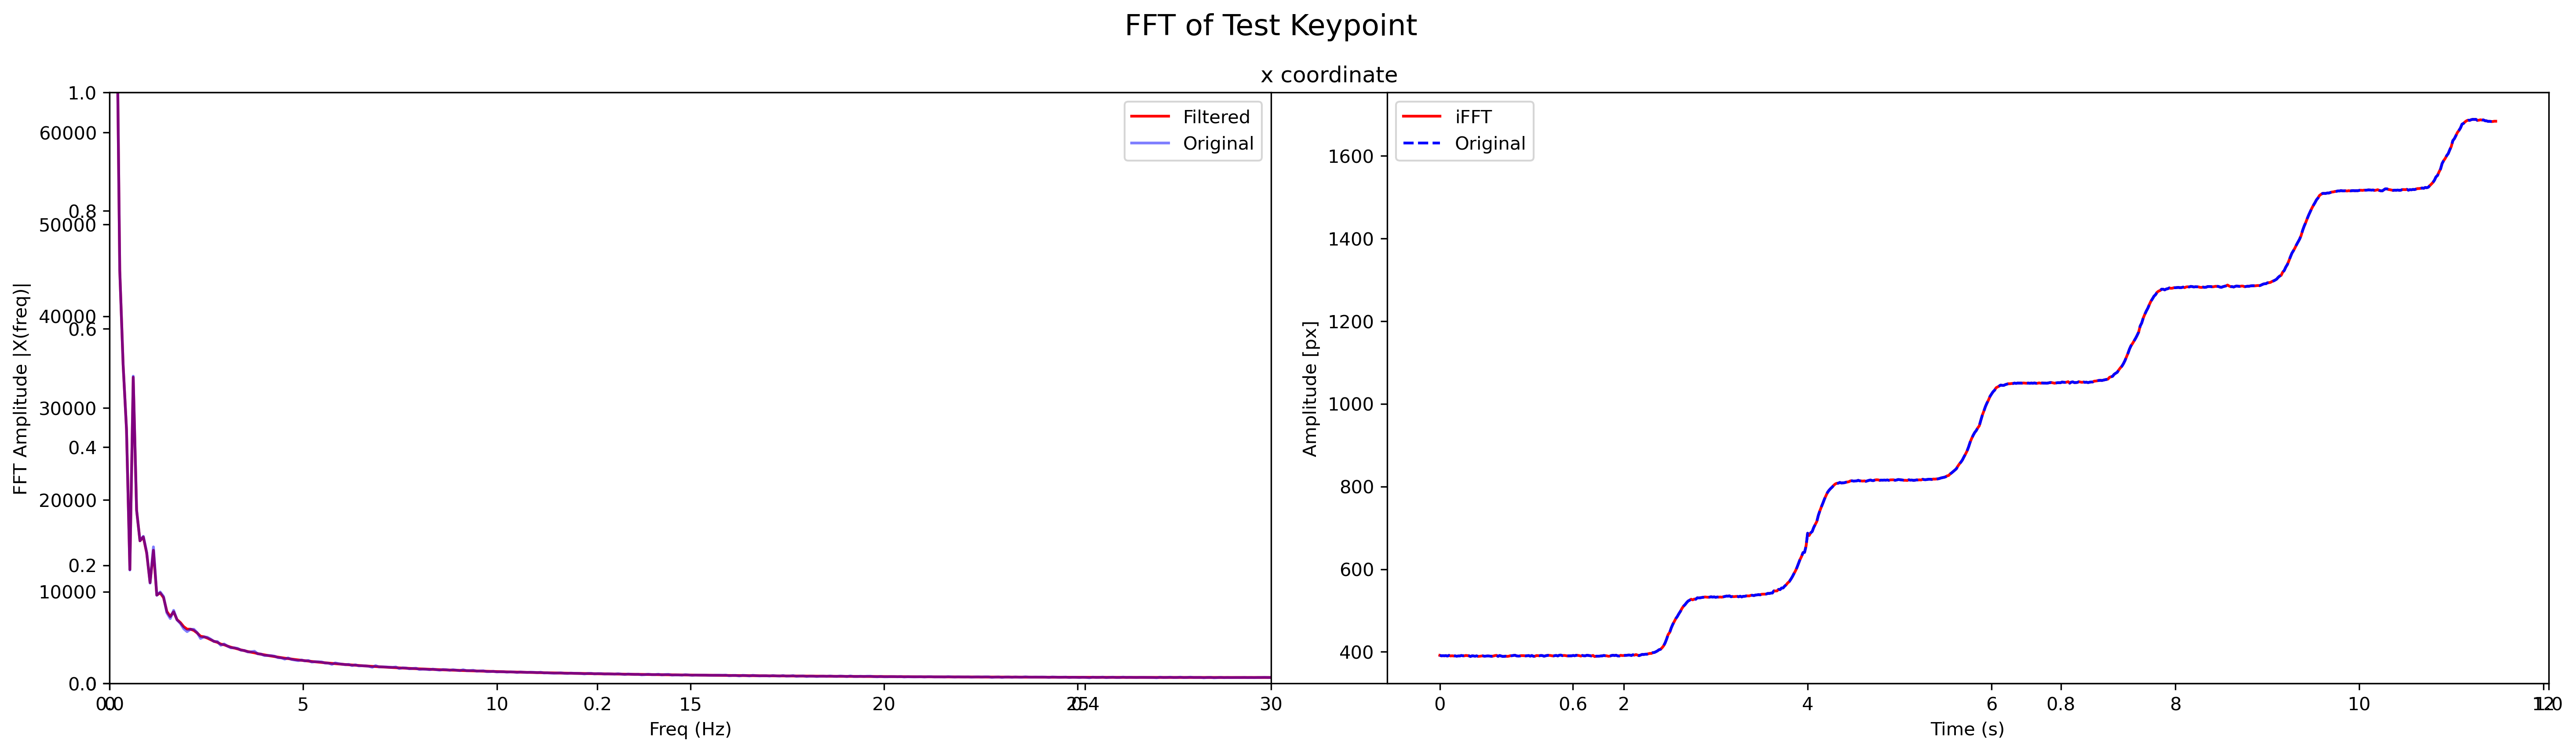

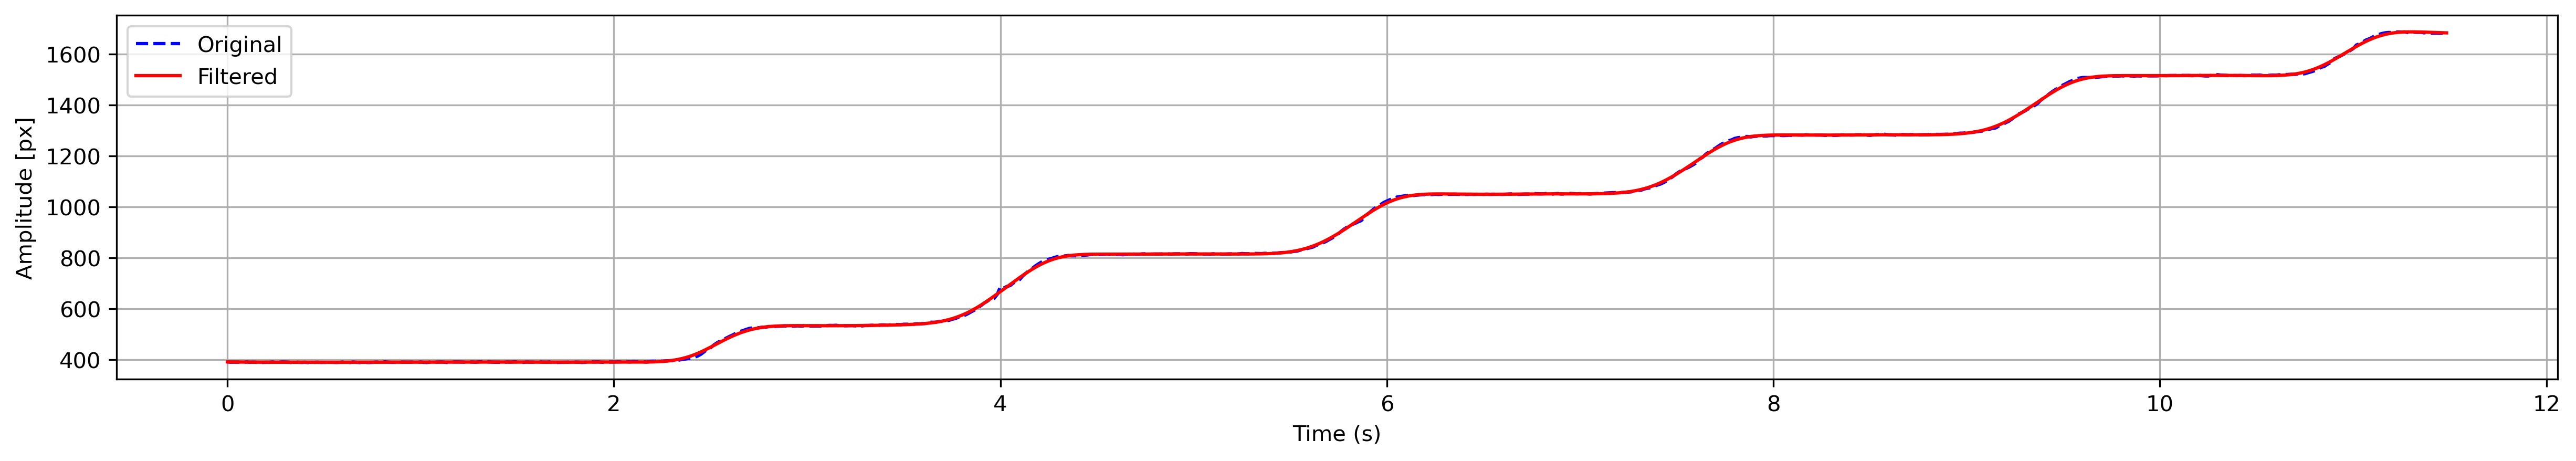

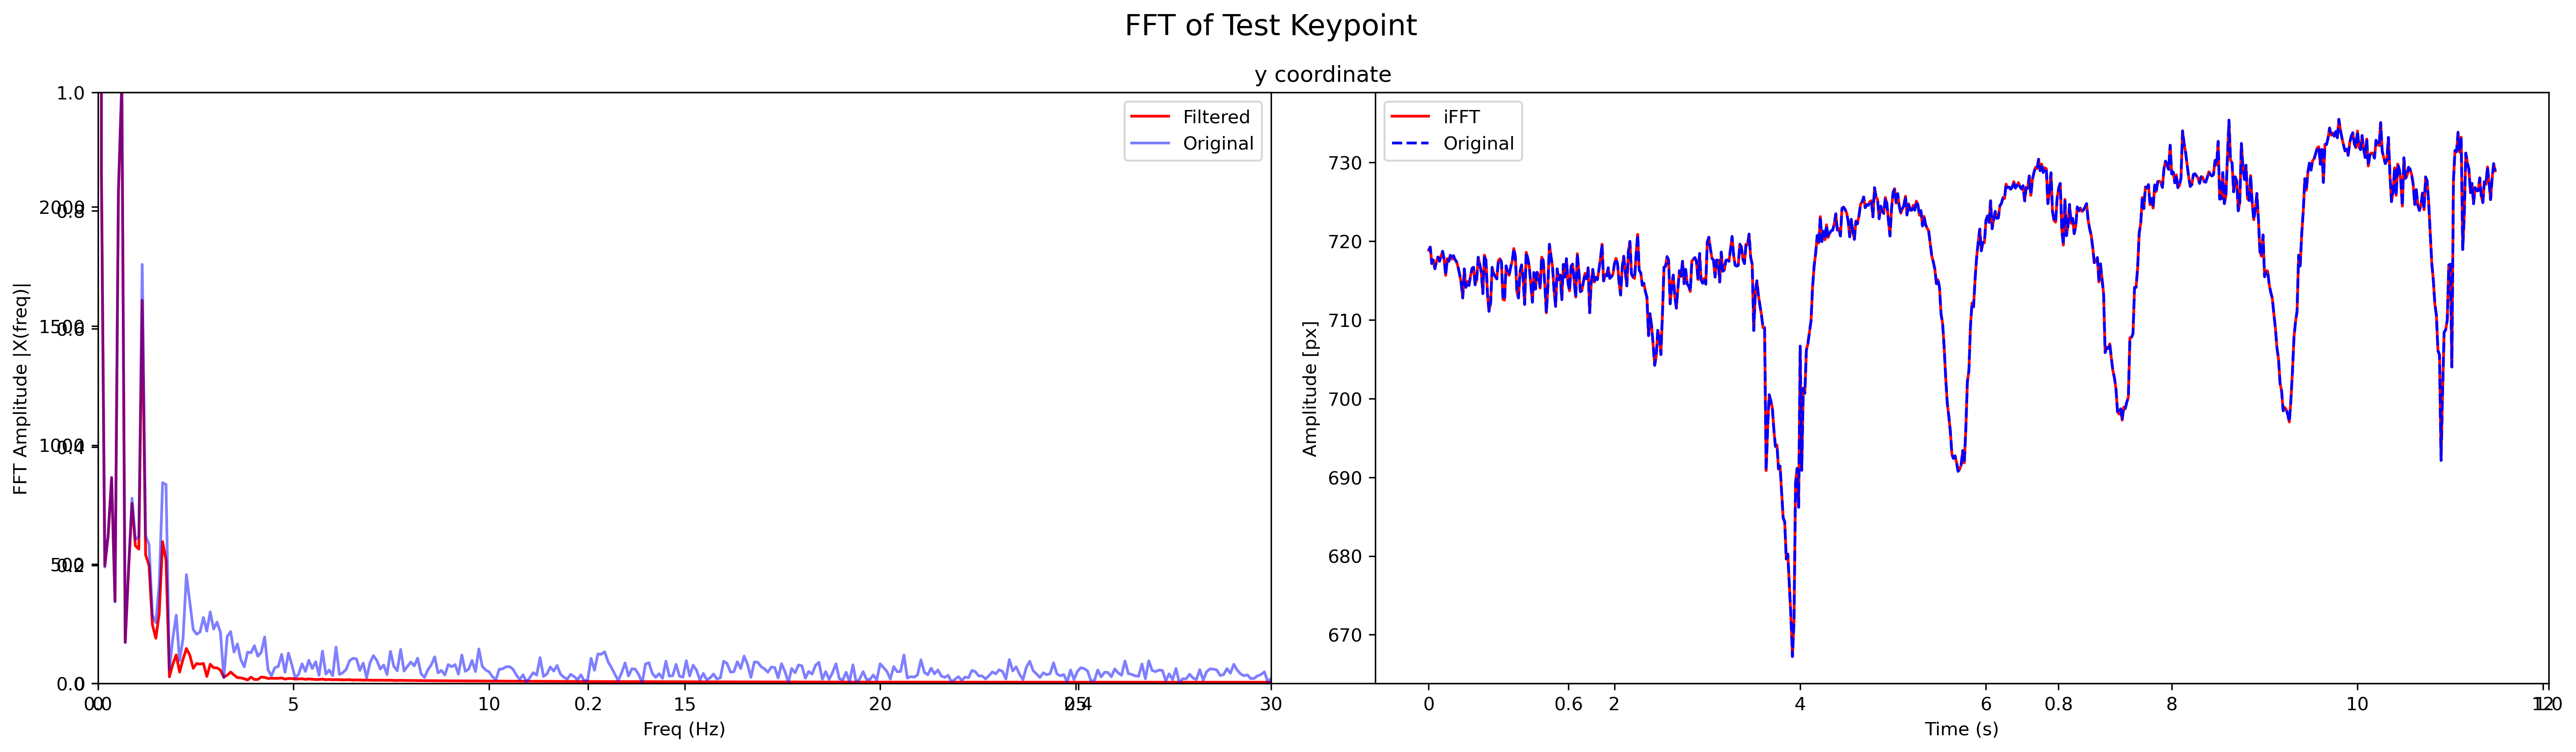

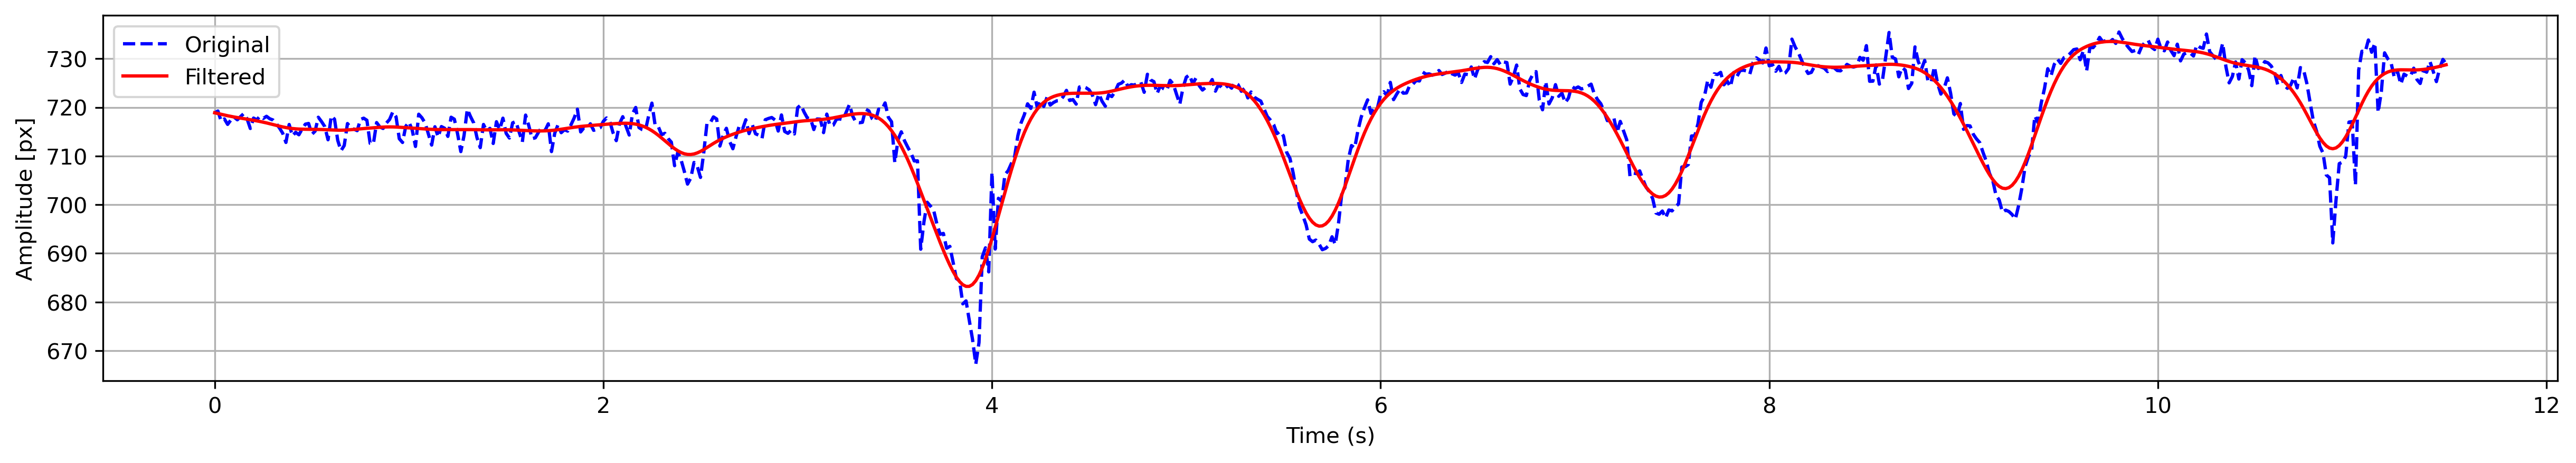

In [10]:
def filter_keypoints(keypoint:np.array, title:str, fr=60, create_diagram=False) -> np.array:
    '''
    Perfortm FFT and low-pass filtering on a single keypoint (e.g.: left elbow, (N, (x,y,conf))).

    Returns the filetered keypoint coordinates (and confidence) in the original shape (N, 3).
    '''

    # x and y coordinates
    kp_x = keypoint[:, 0]
    kp_y = keypoint[:, 1]

    
    filtered_keypoint = np.empty_like(keypoint)
    filtered_x, filtered_y = np.empty_like(kp_x), np.empty_like(kp_y)

    # time
    t = np.arange(0, keypoint.shape[0], 1) / fr

    # filtering parameters
    order = 2
    lowcut = 2 # cut fr for lowpass
    # highpass = 5 # cut fr for highpass
    # bandpass = [0.1, 5]
    b, a = butter(order, lowcut, fs=fr, btype='low', analog=False)

    for coords in [kp_x, kp_y]:

        original = coords.copy()

        # replace NaN values with zeros
        if np.isnan(coords).any():
            print("NaN values found in keypoint data. Replacing with zeros.")
            coords[np.isnan(coords)] = 0
        
        # filtered x or y coords
        filtered_coord = sp_signal.filtfilt(b, a, coords)
    
        if np.array_equiv(coords, kp_x):
            filtered_x = filtered_coord
            subtitle = 'x coordinate'
            yl = 0.1

        elif np.array_equiv(coords, kp_y):
            filtered_y = filtered_coord
            subtitle = 'y coordinate'
            yl = 0.005

        if create_diagram:
            plt.figure(figsize = (20, 6))
            plt.title(subtitle)

            plt.suptitle(f'FFT of {title} Keypoint', fontsize=16)
            colors = ['r','b']

            # perform FFT on each coordinate(x or y), plot results
            for i, signal in enumerate([filtered_coord, original]):
            
                X = fft(signal)
                N = len(X)
                n = np.arange(N)
                T = N/60
                freq = n/T 
                plt.subplot(1,2,1)
                plt.plot(freq, np.abs(X), colors[i], label=f'{title} {["Filtered", "Original"][i]}',alpha=[1,0.5][i])
            
            plt.xlabel('Freq (Hz)')
            plt.ylabel('FFT Amplitude |X(freq)|')
            plt.xlim(0, fr/2)
            ylim = max(np.abs(X)*yl)
            plt.ylim(0,ylim)
            plt.legend(['Filtered','Original'])

            # plot the original and iFFT signals
            plt.subplot(122)
            plt.plot(t, ifft(X), 'r')
            plt.plot(t, original, 'b--')
            plt.xlabel('Time (s)')
            plt.ylabel('Amplitude [px]')
            plt.legend(['iFFT', 'Original'])
            plt.tight_layout()
            plt.show()

            # plot the original and filtered signals
            plt.figure(figsize=(20, 3))
            plt.plot(t, original, 'b--', label='Original')
            plt.plot(t, filtered_coord, 'r', label='Filtered')
            plt.xlabel( 'Time (s)')
            plt.ylabel('Amplitude [px]')
            plt.legend()
            plt.grid()
            plt.show()

        # stack filtered coords, use original confidence
        filtered_keypoint = np.stack([filtered_x, filtered_y, keypoint[:, 2]], axis=1)

    return filtered_keypoint

filtered_coords = filter_keypoints(RAnkle, 'Test', fr=60, create_diagram=True)

In [ ]:
print(filtered_coords.shape)
plt.figure(figsize=(15, 1))
plt.plot(filtered_coords[:, 0], 'r')

In [6]:
filtered_data = {
    'filtered_coords': filtered_coords,
    'keypoint_id': 16,
    'max_keypoints': 26 
}
keypoints_over_time[:,filtered_data['keypoint_id']] = filtered_data['filtered_coords']

In [ ]:
keypoints_over_time_transposed = keypoints_over_time.transpose(1, 0, 2)
print(keypoints_over_time_transposed.shape)

In [17]:
from tqdm import tqdm


filename = 'ken_walking_side_short'
keypoints_over_time = np.load(f'./saved_coords/validation_test/{filename}.npy')
keypoints_over_time.shape


filtered_data = []

for keypoint_id, keypoint in enumerate(keypoints_over_time.transpose(1, 0, 2)):

    print(f'input shape: {keypoint.shape},  keypoint_id: {keypoint_id}')
    result = filter_keypoints(keypoint, f'{keypoint_id}', fr=60, create_diagram=False)
    # filtered_data = np.stack([filtered_data, result], axis=0)
    filtered_data.append(result)

    print(f'output shape: {result.shape}')
    
    # if keypoint_id == 2:
    #     break


filtered_data = np.array(filtered_data).transpose(1, 0, 2)
print("Filtered data shape:", np.array(filtered_data).shape)

input shape: (690, 3),  keypoint_id: 0
output shape: (690, 3)
input shape: (690, 3),  keypoint_id: 1
output shape: (690, 3)
input shape: (690, 3),  keypoint_id: 2
output shape: (690, 3)
input shape: (690, 3),  keypoint_id: 3
output shape: (690, 3)
input shape: (690, 3),  keypoint_id: 4
output shape: (690, 3)
input shape: (690, 3),  keypoint_id: 5
output shape: (690, 3)
input shape: (690, 3),  keypoint_id: 6
output shape: (690, 3)
input shape: (690, 3),  keypoint_id: 7
output shape: (690, 3)
input shape: (690, 3),  keypoint_id: 8
output shape: (690, 3)
input shape: (690, 3),  keypoint_id: 9
output shape: (690, 3)
input shape: (690, 3),  keypoint_id: 10
output shape: (690, 3)
input shape: (690, 3),  keypoint_id: 11
output shape: (690, 3)
input shape: (690, 3),  keypoint_id: 12
output shape: (690, 3)
input shape: (690, 3),  keypoint_id: 13
output shape: (690, 3)
input shape: (690, 3),  keypoint_id: 14
output shape: (690, 3)
input shape: (690, 3),  keypoint_id: 15
output shape: (690, 3)
in

## Playback

In [21]:
import cv2
import time

video_path = f'./stereo_videos/validation_test/{filename}.mp4'
cap = cv2.VideoCapture(video_path)
total_num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Define codec and create VideoWriter to save output (optional)
# fourcc = cv2.VideoWriter_fourcc(*'mp4v')
# out = cv2.VideoWriter('output_overlay.mp4', fourcc, cap.get(cv2.CAP_PROP_FPS), (int(cap.get(3)), int(cap.get(4))))

# keypoints_over_time[:,filtered_data['keypoint_id'], :] = filtered_data['filtered_coords']
keypoints_over_time = filtered_data



frame_idx = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret or frame_idx >= keypoints_over_time.shape[0]:
        break

    # Overlay all keypoints for this frame
    for ind, (x, y, confidence) in enumerate(keypoints_over_time[frame_idx]):
        # Ensure x and y are finite numbers before drawing
        if np.isfinite(x) and np.isfinite(y):
            try: 
                if ind in []:
                    cv2.circle(frame, (int(x), int(y)), 5, (255,0,0), 5)
                    # cv2.putText(frame, f'LHip: {confidence:.2f}', (int(x) + 10, int(y) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
                else:
                    cv2.circle(frame, (int(round(x)), int(round(y))), 4, (0, int(confidence * 255), 255 - int(255 * confidence)), -1)
            except Exception as e:
                print(f"Error drawing circle for keypoint {ind}: x={x}, y={y}, confidence={confidence}, error={e}")

    cv2.putText(frame, f'Frame: {frame_idx + 1}/{total_num_frames}', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    # Draw a color gradient for confidence levels            
    for i in range(0,11,1):
        cv2.circle(frame, (50, 500-i*30), 4, (0, i*255/10,255-255*i/10), -1)  
        cv2.putText(frame, f'{i/10}', (60, 500-i*30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    # Resize and display the frame
    cv2.imshow('Coords',cv2.resize(frame, (int(frame.shape[1] / 1.5), int(frame.shape[0] / 1.5))))
    time.sleep(0.05)
    # out.write(frame)  # Uncomment to save output

    # press 'q' to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

    frame_idx += 1

cap.release()
# out.release()
cv2.destroyAllWindows()

In [ ]:
filtered_coords[0]

In [ ]:
print((type(keypoints_over_time),type(filtered_coords)))
print(keypoints_over_time.shape, filtered_coords.shape)

In [66]:
from scipy.signal import butter
from scipy import signal

plt.figure(figsize=(20, 5))
# unfiltered_signal = keypoint-np.mean(keypoint)
unfiltered_signal = keypoint
plt.plot(t[:100],  unfiltered_signal[:100], 'b--', label='Unfiltered Signal')

for order in range(1,4,1):
    # order = 2
    lowcut = 2
    highpass = 5
    fs = 60

    b, a = butter(order, lowcut, fs=fs, btype='low', analog=False)
    # b, a = butter(order, highpass, fs=fs, btype='high', analog=False)
    # b, a = butter(order, [lowcut,highcut], fs=fs, btype='bandpass', analog=False)

    filtered_signal = signal.filtfilt(b, a, keypoint)


    plt.plot(t[:100], filtered_signal[:100],label=f'order={order}')

    print(order)
    
plt.legend()

filtered_signal.shape




NameError: name 't' is not defined

<Figure size 6000x1500 with 0 Axes>

In [ ]:
uniformat = {
    "Nose": [],
    "LEye": [],
    "REye": [],
    "LEar": [],
    "REar": [],
    "LShoulder": [],
    "RShoulder": [],
    "LElbow": [],
    "RElbow": [],
    "LWrist": [],
    "RWrist": [],
    "LHip": [],
    "RHip": [],
    "LKnee": [],
    "Rknee": [],
    "LAnkle": [],
    "RAnkle": [],
    "Head": [],
    "Neck": [],
    "Hip": [],
    "LBigToe": [],
    "RBigToe": [],
    "LSmallToe": [],
    "RSmallToe": [],
    "LHeel": [],
    "RHeel": [],
}